# 01. Загрузка и первичный анализ данных comma.ai

- подключаем файлы `log/*.h5`;
- смотрим структуру данных;
- делаем базовый EDA (распределения, пропуски, выбросы).

В дальнейшем эти данные будут использоваться для задачи классификации манёвра
(прямо / левый поворот / правый поворот) по телеметрии автомобиля.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_ROOT = Path("../data/raw/dataset/log")
print("DATA_ROOT:", DATA_ROOT.resolve())
print("Data path exists:", DATA_ROOT.exists())

ModuleNotFoundError: No module named 'h5py'

In [1]:
# Проверка распаковки файлов
from pathlib import Path

DATA_ROOT = Path("../data/raw/dataset/log")
h5_files = sorted(DATA_ROOT.glob("*.h5"))
print(f"Найдено файлов: {len(h5_files)}")
for p in h5_files[:10]:
    print(" ", p.name)

Найдено файлов: 11
  2016-01-30--11-24-51.h5
  2016-01-30--13-46-00.h5
  2016-01-31--19-19-25.h5
  2016-02-02--10-16-58.h5
  2016-02-08--14-56-28.h5
  2016-02-11--21-32-47.h5
  2016-03-29--10-50-20.h5
  2016-04-21--14-48-08.h5
  2016-05-12--22-20-00.h5
  2016-06-02--21-39-29.h5


In [2]:
# пробуем читать формат первого файла 
import h5py

# берём первый файл
sample_file = h5_files[0]
print("Файл:", sample_file.name)
print()

with h5py.File(sample_file, "r") as f:
    print("Ключи верхнего уровня:")
    for key in f.keys():
        item = f[key]
        if hasattr(item, "shape"):
            print(f"  {key}: shape={item.shape}, dtype={item.dtype}")
        else:
            print(f"  {key}/ (группа)")
            for subkey in item.keys():
                sub = item[subkey]
                if hasattr(sub, "shape"):
                    print(f"    {subkey}: shape={sub.shape}, dtype={sub.dtype}")

Файл: 2016-01-30--11-24-51.h5

Ключи верхнего уровня:
  UN_D_cam1_ptr: shape=(52723,), dtype=int64
  UN_D_cam2_ptr: shape=(52702,), dtype=int64
  UN_D_camphone_ptr: shape=(78588,), dtype=int64
  UN_D_lidar_ptr: shape=(4766772,), dtype=int64
  UN_D_radar_msg: shape=(652149, 7), dtype=float64
  UN_D_rawgps: shape=(110526,), dtype=|S233
  UN_T_cam1_ptr: shape=(52723,), dtype=float64
  UN_T_cam2_ptr: shape=(52702,), dtype=float64
  UN_T_camphone_ptr: shape=(78588,), dtype=float64
  UN_T_lidar_ptr: shape=(4766772,), dtype=float64
  UN_T_radar_msg: shape=(652149,), dtype=float64
  UN_T_rawgps: shape=(110526,), dtype=float64
  blinker: shape=(263583,), dtype=float64
  brake: shape=(263583,), dtype=float64
  brake_computer: shape=(263583,), dtype=float64
  brake_user: shape=(263583,), dtype=float64
  cam1_ptr: shape=(263583,), dtype=float64
  cam2_ptr: shape=(263583,), dtype=float64
  camphone_ptr: shape=(263583,), dtype=float64
  car_accel: shape=(263583,), dtype=float64
  fiber_accel: shape=

In [3]:
import pandas as pd
import numpy as np

def load_trip(filepath):
    """Загружает одну поездку из .h5 в DataFrame с нужными каналами."""
    cols = {
        "times":            "t",
        "speed":            "speed",
        "steering_angle":   "steering_angle",
        "car_accel":        "car_accel",
        "imu_accel":        None,   # 3 колонки
        "imu_gyro":         None,   # 3 колонки
        "gas":              "gas",
        "brake":            "brake",
        "rpm":              "rpm",
    }
    with h5py.File(filepath, "r") as f:
        df = pd.DataFrame()
        df["t"]               = f["times"][:]
        df["speed"]           = f["speed"][:]
        df["steering_angle"]  = f["steering_angle"][:]
        df["car_accel"]       = f["car_accel"][:]
        df["gas"]             = f["gas"][:]
        df["brake"]           = f["brake"][:]
        df["rpm"]             = f["rpm"][:]

        # imu_accel: 3 оси
        imu_a = f["imu_accel"][:]
        df["imu_ax"] = imu_a[:, 0]
        df["imu_ay"] = imu_a[:, 1]
        df["imu_az"] = imu_a[:, 2]

        # imu_gyro: 3 оси
        imu_g = f["imu_gyro"][:]
        df["imu_gx"] = imu_g[:, 0]
        df["imu_gy"] = imu_g[:, 1]
        df["imu_gz"] = imu_g[:, 2]

        df["trip"] = filepath.stem  # имя файла как ID поездки

    return df

# Загружаем первую поездку
df = load_trip(h5_files[0])
print(f"Размер: {df.shape}")
print(f"\nПервые строки:")
df.head()

Размер: (263583, 14)

Первые строки:


,t,speed,steering_angle,car_accel,gas,brake,rpm,imu_ax,imu_ay,imu_az,imu_gx,imu_gy,imu_gz,trip
0,0.00,0.0,80.0,0.0,0.0,63872.0,0.0,-0.310000,9.640000,-0.330000,0.000000,-0.062500,0.000000,2016-01-30--11-24-51
1,0.01,0.0,80.0,0.0,0.0,63872.0,0.0,-0.314084,9.631832,-0.321832,0.000000,-0.062500,-0.025527,2016-01-30--11-24-51
2,0.02,0.0,80.0,0.0,0.0,63872.0,0.0,-0.310612,9.624694,-0.314694,0.058672,-0.033164,-0.091836,2016-01-30--11-24-51
3,0.03,0.0,80.0,0.0,0.0,63872.0,0.0,-0.304536,9.632268,-0.322268,0.082473,-0.014176,-0.110824,2016-01-30--11-24-51
4,0.04,0.0,80.0,0.0,0.0,63872.0,0.0,-0.317773,9.637773,-0.347814,-0.034666,-0.048583,-0.048583,2016-01-30--11-24-51


In [4]:
print("=== Базовая статистика ===")
df.describe().round(3)

=== Базовая статистика ===


,t,speed,steering_angle,car_accel,gas,brake,rpm,imu_ax,imu_ay,imu_az,imu_gx,imu_gy,imu_gz
count,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000,263583.000
mean,1317.910,18.470,22.495,-0.007,0.116,236.890,1561.697,-0.392,9.560,-0.641,-0.011,0.066,-0.137
std,760.900,12.710,605.378,0.713,0.142,1990.972,610.490,0.841,0.547,0.538,1.165,4.038,1.140
min,0.000,-1.832,-5121.000,-4.597,0.000,-64.000,0.000,-6.211,2.561,-6.343,-18.369,-39.682,-18.464
25%,658.955,4.734,-13.000,-0.269,0.000,0.000,1049.885,-0.727,9.334,-0.861,-0.494,-0.291,-0.563
50%,1317.910,25.934,2.000,0.000,0.000,0.000,1710.796,-0.397,9.571,-0.652,0.000,-0.007,-0.062
75%,1976.865,30.029,18.585,0.226,0.227,128.000,1892.702,-0.046,9.780,-0.449,0.471,0.244,0.276
max,2635.820,35.880,5011.000,5.121,1.000,63872.000,5276.592,8.571,19.113,6.952,25.365,54.415,21.609


In [5]:
print("=== Пропуски ===")
print(df.isnull().sum())
print(f"\nДоля пропусков: {df.isnull().sum().sum() / df.size:.4%}")

=== Пропуски ===
t                 0
speed             0
steering_angle    0
car_accel         0
gas               0
brake             0
rpm               0
imu_ax            0
imu_ay            0
imu_az            0
imu_gx            0
imu_gy            0
imu_gz            0
trip              0
dtype: int64

Доля пропусков: 0.0000%


Matplotlib is building the font cache; this may take a moment.


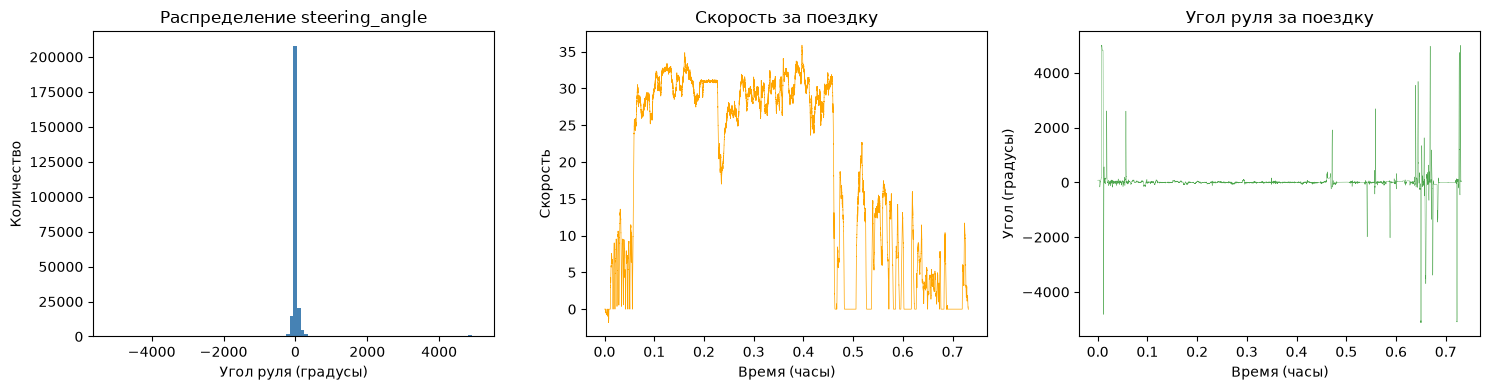

График сохранён в reports/eda_trip1.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма угла руля
axes[0].hist(df["steering_angle"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Распределение steering_angle")
axes[0].set_xlabel("Угол руля (градусы)")
axes[0].set_ylabel("Количество")

# Скорость во времени
axes[1].plot(df["t"] / 3600, df["speed"], lw=0.5, color="orange")
axes[1].set_title("Скорость за поездку")
axes[1].set_xlabel("Время (часы)")
axes[1].set_ylabel("Скорость")

# Угол руля во времени
axes[2].plot(df["t"] / 3600, df["steering_angle"], lw=0.3, color="green", alpha=0.7)
axes[2].set_title("Угол руля за поездку")
axes[2].set_xlabel("Время (часы)")
axes[2].set_ylabel("Угол (градусы)")

plt.tight_layout()
plt.savefig("../reports/eda_trip1.png", dpi=120)
plt.show()
print("График сохранён в reports/eda_trip1.png")

1-й перцентиль:  -1684.3°
99-й перцентиль: 2569.6°

Выбросов (|angle| > 540°): 10917 (4.142%)

После фильтрации: 252666 строк (95.9%)
Реальный диапазон angle: [-539.9°, 539.9°]


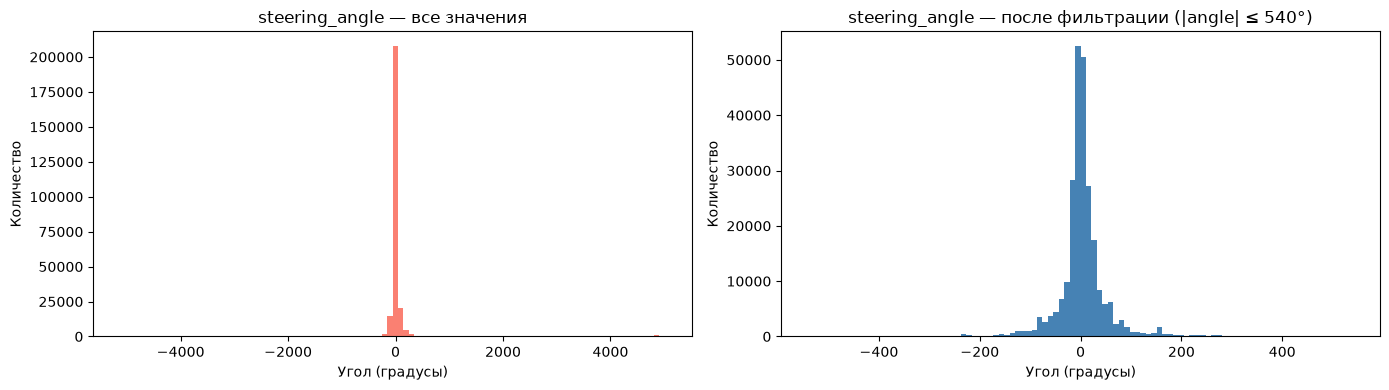

In [9]:
# Смотрим распределение с новым порогом ±540°
q_low  = df["steering_angle"].quantile(0.01)
q_high = df["steering_angle"].quantile(0.99)
print(f"1-й перцентиль:  {q_low:.1f}°")
print(f"99-й перцентиль: {q_high:.1f}°")

# Сколько точек за пределами ±540°
OUTLIER_THRESHOLD = 540
outliers = df["steering_angle"].abs() > OUTLIER_THRESHOLD
print(f"\nВыбросов (|angle| > {OUTLIER_THRESHOLD}°): {outliers.sum()} ({outliers.mean():.3%})")

# Статистика по «нормальным» значениям
df_clean = df[~outliers]
print(f"\nПосле фильтрации: {len(df_clean)} строк ({len(df_clean)/len(df):.1%})")
print(f"Реальный диапазон angle: [{df_clean['steering_angle'].min():.1f}°, {df_clean['steering_angle'].max():.1f}°]")

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# До фильтрации
axes[0].hist(df["steering_angle"], bins=100, color="salmon", edgecolor="none")
axes[0].set_title("steering_angle — все значения")
axes[0].set_xlabel("Угол (градусы)")
axes[0].set_ylabel("Количество")

# После фильтрации
axes[1].hist(df_clean["steering_angle"], bins=100, color="steelblue", edgecolor="none")
axes[1].set_title(f"steering_angle — после фильтрации (|angle| ≤ {OUTLIER_THRESHOLD}°)")
axes[1].set_xlabel("Угол (градусы)")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig("../reports/eda_steering_clean_540.png", dpi=120)
plt.show()

Строк после фильтрации: 252666 (95.9%)

Распределение классов:
maneuver_class
straight      101987
turn_right     82347
turn_left      68332
Name: count, dtype: int64

Доля классов:
maneuver_class
straight      0.404
turn_right    0.326
turn_left     0.270
Name: count, dtype: float64


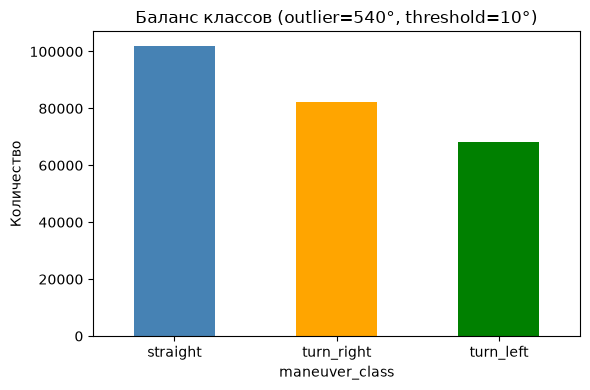

In [10]:
OUTLIER_THRESHOLD = 540  # физически обоснованный порог
STEER_THRESHOLD   = 10   # порог для классификации манёвра

df_valid = df[df["steering_angle"].abs() <= OUTLIER_THRESHOLD].copy()
print(f"Строк после фильтрации: {len(df_valid)} ({len(df_valid)/len(df):.1%})")

def make_label(angle):
    if angle > STEER_THRESHOLD:
        return "turn_right"
    elif angle < -STEER_THRESHOLD:
        return "turn_left"
    else:
        return "straight"

df_valid["maneuver_class"] = df_valid["steering_angle"].apply(make_label)

counts = df_valid["maneuver_class"].value_counts()
print("\nРаспределение классов:")
print(counts)
print("\nДоля классов:")
print((counts / len(df_valid)).round(3))

counts.plot(kind="bar", color=["steelblue", "orange", "green"],
            figsize=(6, 4), title=f"Баланс классов (outlier={OUTLIER_THRESHOLD}°, threshold={STEER_THRESHOLD}°)")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/class_balance_v2.png", dpi=120)
plt.show()

**Итог первого ноутбука**

- Проверил наличие и состав 11 файлов .h5.
- Посмотрел структуру одного файла и ключи с данными.
- Собрал датафрейм с основными телеметрическими признаками для поездки.